In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix, roc_auc_score,roc_curve, RocCurveDisplay
print("Libraries imported")

Libraries imported


# Loading Dataset

In [3]:
df_data= pd.read_csv("Employee_Attrition.csv")
df_data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# Data cleaning Validation

In [4]:
df_data.shape

(1470, 35)

In [5]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df_data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
df_data.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df_data.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis

In [9]:
# Univariate Analysis

In [10]:
df_data["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [11]:
# Check for Percentage for Attrition

df_data["Attrition"].value_counts(normalize=True) *100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

# Bivariate Analysis

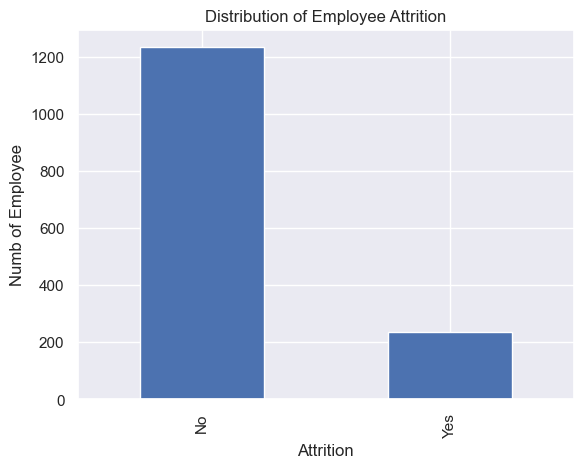

In [12]:
df_data["Attrition"].value_counts().plot(kind="bar")
plt.title("Distribution of Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Numb of Employee")
plt.show()

In [13]:
# select the numerical columns

num_cols = df_data.select_dtypes(include=["int64", "float"]).columns

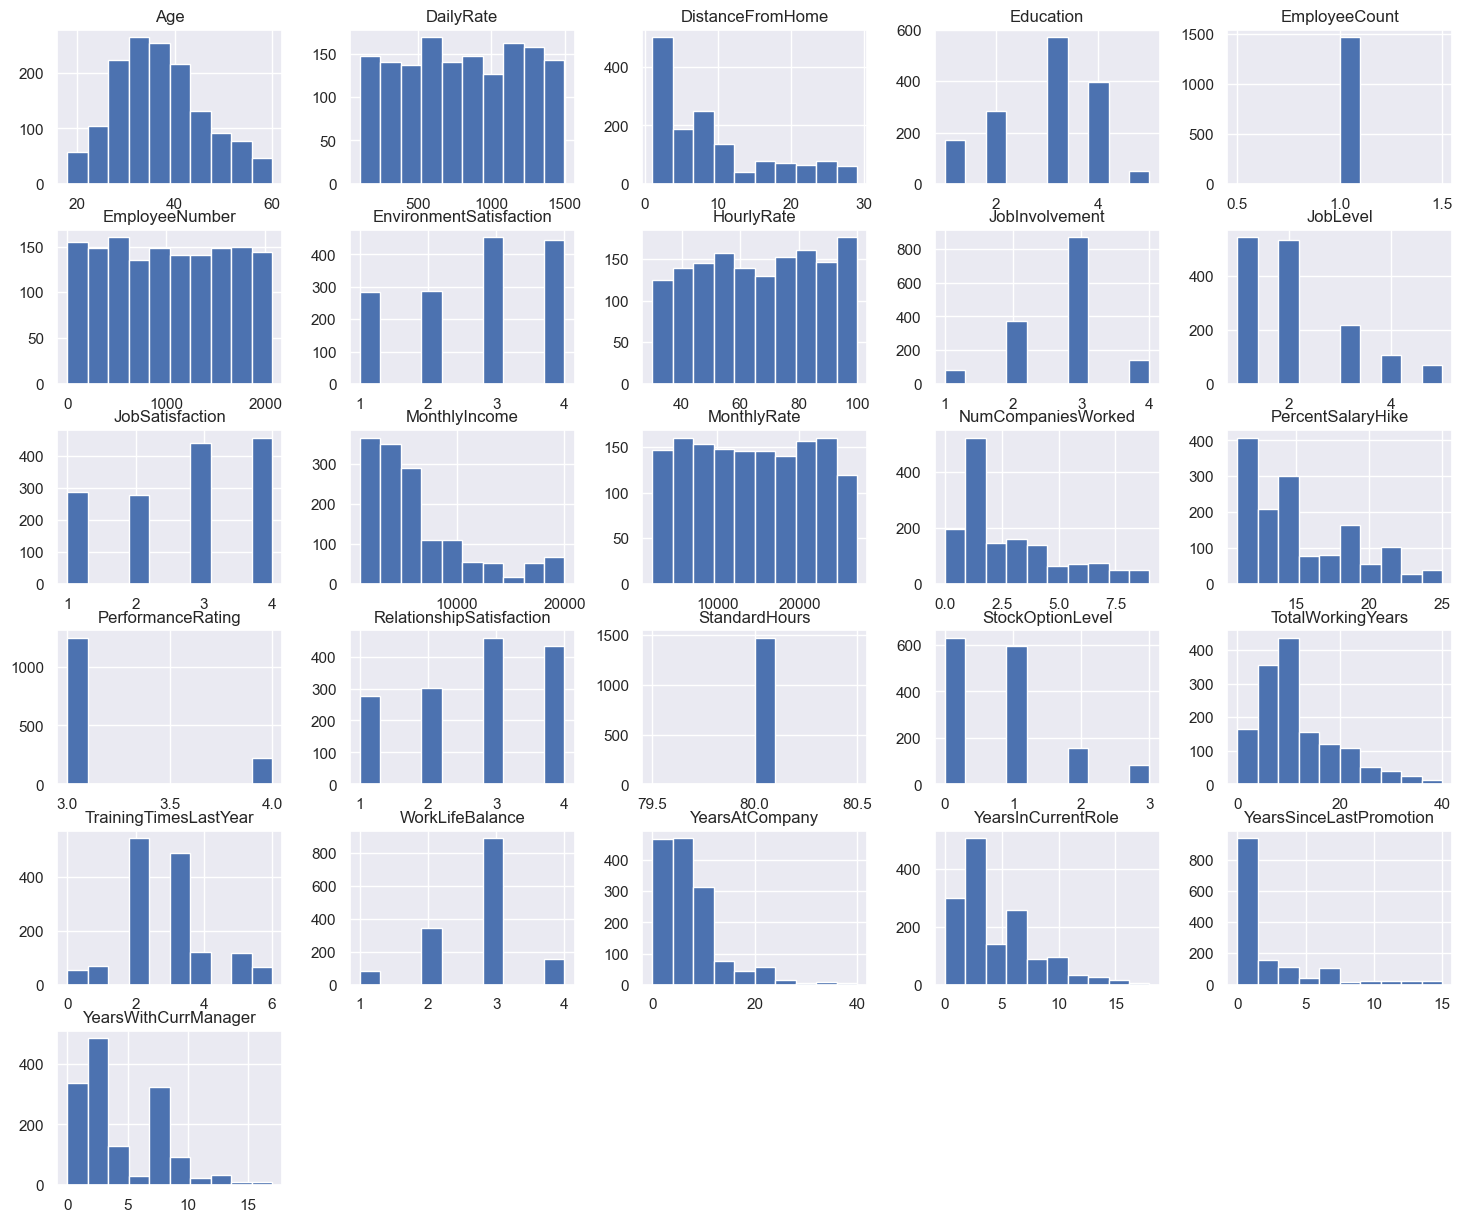

In [14]:
# to check the Skewness and Distribution for numerical columns

df_data[num_cols].hist(figsize=(18,15))
plt.show()

In [15]:
#  Select the categorical columns

cat_cols = df_data.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\n{col}")
    print(df_data[col].value_counts())


Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     673


# Univariate Anslysis

In [16]:
pd.crosstab(df_data["OverTime"], df_data["Attrition"])

# The employees who work overtime are more likely to leave the company then who do not, 
# fewer empolyees of (127) who work overtime left the company,compared (110) of employees who did not work overtime,
# this suggest that overtime may be a strong prediction of employees attition.

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


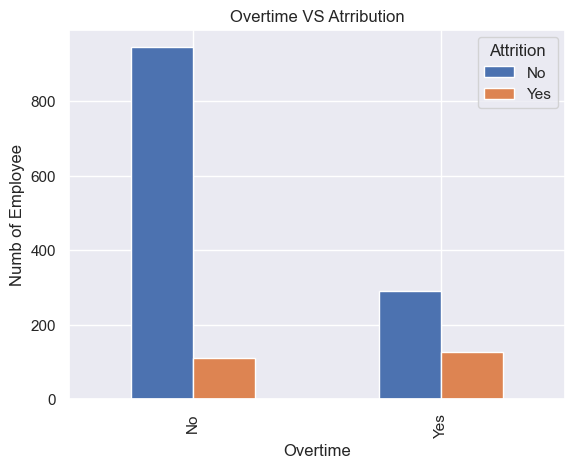

In [17]:
pd.crosstab(df_data["OverTime"], 
            df_data["Attrition"]).plot(kind="bar")

plt.title("Overtime VS Atrribution")
plt.xlabel("Overtime")
plt.ylabel("Numb of Employee")
plt.show()

In [18]:
pd.crosstab(df_data["Department"], df_data["Attrition"])

# The Research and Department has the higher  numb of employees who left the company (133), 
# followed by Sales (92), and Human Resourtces (12).

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


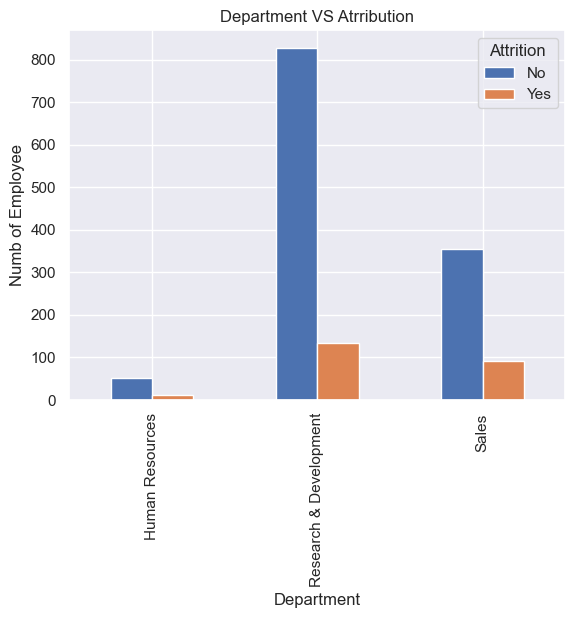

In [19]:
pd.crosstab(df_data["Department"], 
            df_data["Attrition"]).plot(kind="bar")

plt.title("Department VS Atrribution")
plt.xlabel("Department")
plt.ylabel("Numb of Employee")
plt.show()

In [20]:
pd.crosstab(df_data["Gender"], df_data["Attrition"])

# for Gender the male employees (150) left the company then femal emplyees(87).

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


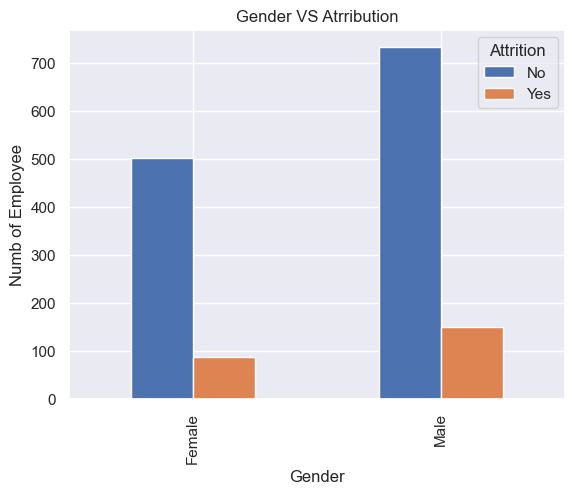

In [21]:
pd.crosstab(df_data["Gender"], 
            df_data["Attrition"]).plot(kind="bar")

plt.title("Gender VS Atrribution")
plt.xlabel("Gender")
plt.ylabel("Numb of Employee")
plt.show()

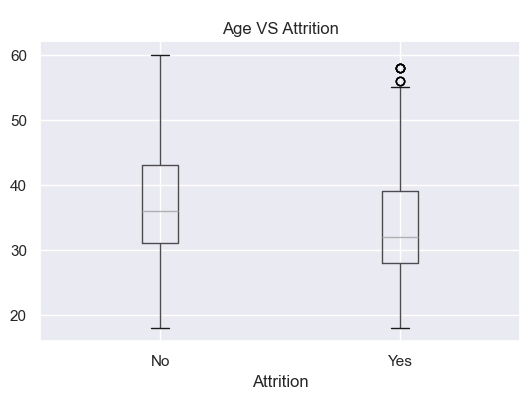

In [22]:
df_data.boxplot(column="Age", by="Attrition", figsize=(6,4))
plt.title("Age VS Attrition")
plt.suptitle(" ")
plt.show()

# Insite : The boxplot show that employee whos left the company tend to be slightly younger than whos stayed, base on the median 

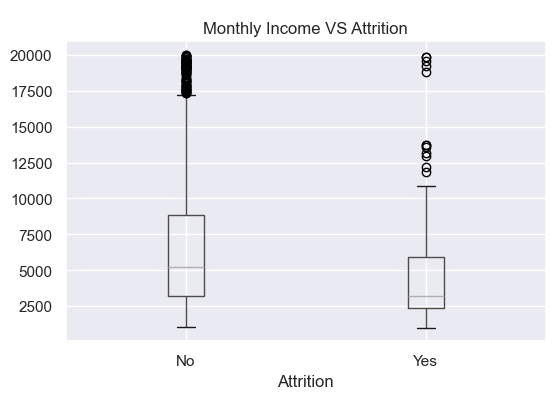

In [23]:
df_data.boxplot(column="MonthlyIncome", by="Attrition", figsize=(6,4))

plt.title("Monthly Income VS Attrition")
plt.suptitle(" ")
plt.show()

# Insite : employees who left the company generaly have lower monthly incomes than thoes who remanin. 
         # this show that salary can be associated with a higher likelihood of employee attrition.


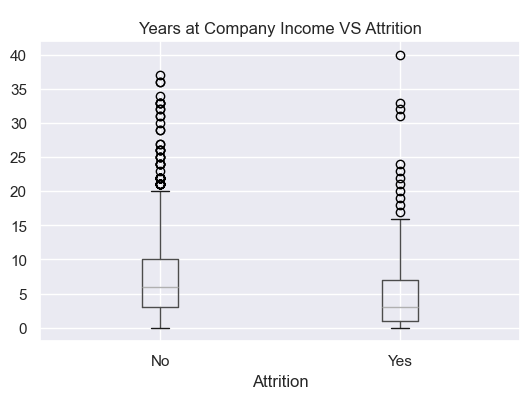

In [24]:
df_data.boxplot(column="YearsAtCompany", by="Attrition", figsize=(6,4))
plt.title("Years at Company Income VS Attrition")
plt.suptitle(" ")
plt.show()


# Insite: Employees who left the company generaly have fewer years of service than thoes stayed. 
# This indicates that attrition common among relatively new employees.

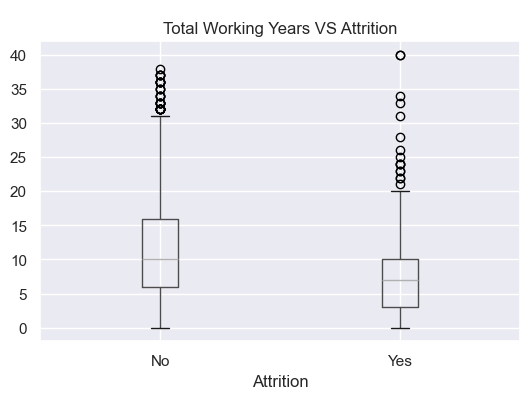

In [25]:
df_data.boxplot(column="TotalWorkingYears", by="Attrition", figsize=(6,4))
plt.title("Total Working Years VS Attrition")
plt.suptitle(" ")
plt.show()

# Insite: Employees with fewer total of work experience  appear more likely to leave tha compnay.
# Thoes with higher work experience tend to remain at company.

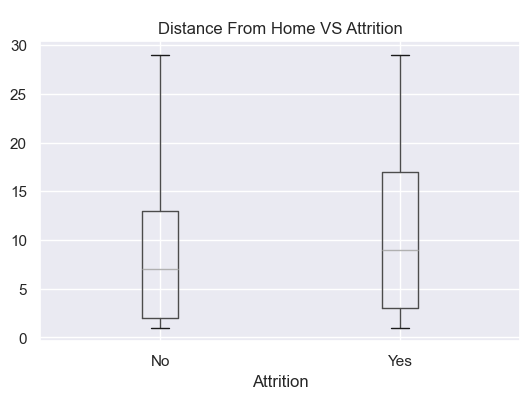

In [26]:
df_data.boxplot(column="DistanceFromHome", by="Attrition", figsize=(6,4))
plt.title("Distance From Home VS Attrition")
plt.suptitle(" ")
plt.show()

# Insied: Employees who left the company have slightly higher median comunity distance .
# However, this indicate that distance from home is not strong prediction for attrition.

# Data Preprocessing

In [27]:
# Check for Constance columns 

df_data.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [28]:
df_data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [29]:
df_data= df_data.drop(columns=["Over18","EmployeeCount", "StandardHours"])

# so thoes three columns was drops because they have only one unique values for every employee

In [30]:
df_data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,3,4,0,17,3,2,9,6,0,8


# Separate Feature and Target Variable

In [31]:
x = df_data.drop("Attrition", axis=1)
y =  df_data["Attrition"]

In [32]:
y

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
1465     No
1466     No
1467     No
1468     No
1469     No
Name: Attrition, Length: 1470, dtype: object

In [33]:
# Encode the Target Variable

y = df_data["Attrition"].map({"No":0, "Yes":1})
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [34]:
x.select_dtypes(include="object").columns.tolist()

['BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [35]:
# Encode the Category Variable to Numerical variable

x = pd.get_dummies(x, drop_first = True, dtype=int)
x

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,2,94,3,2,4,...,0,0,0,0,0,1,0,0,1,1
1,49,279,8,1,2,3,61,2,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1373,2,2,4,4,92,2,1,3,...,1,0,0,0,0,0,0,0,1,1
3,33,1392,3,4,5,4,56,3,1,3,...,0,0,0,0,1,0,0,1,0,1
4,27,591,2,1,7,1,40,3,1,2,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,2061,3,41,4,2,4,...,1,0,0,0,0,0,0,1,0,0
1466,39,613,6,1,2062,4,42,2,3,1,...,0,0,0,0,0,0,0,1,0,0
1467,27,155,4,3,2064,2,87,4,2,2,...,0,0,1,0,0,0,0,1,0,1
1468,49,1023,2,3,2065,4,63,2,2,2,...,0,0,0,0,0,1,0,1,0,0


In [36]:
# scaled the X feature to standard scaled

scaled = StandardScaler()
scaledx = scaled.fit_transform(x)

In [37]:
scaledx

array([[ 0.4463504 ,  0.74252653, -1.01090934, ..., -0.91892141,
         1.45864991,  1.59174553],
       [ 1.32236521, -1.2977746 , -0.14714972, ...,  1.08823234,
        -0.68556546, -0.62824112],
       [ 0.008343  ,  1.41436324, -0.88751511, ..., -0.91892141,
         1.45864991,  1.59174553],
       ...,
       [-1.08667552, -1.60518328, -0.64072665, ...,  1.08823234,
        -0.68556546,  1.59174553],
       [ 1.32236521,  0.54667746, -0.88751511, ...,  1.08823234,
        -0.68556546, -0.62824112],
       [-0.32016256, -0.43256792, -0.14714972, ...,  1.08823234,
        -0.68556546, -0.62824112]])

 # Split Data into training and testing

In [38]:
x_train, x_test, y_train, y_test = train_test_split(scaledx , y , test_size= 0.2 , random_state = 42 , stratify = y )

# Comment: stratify Y tell the tain and testing to keep the same proportion of each class , to make it balance for training and testing.

In [39]:
x_test

array([[-1.41518107,  0.06821073,  0.46982144, ...,  1.08823234,
        -0.68556546, -0.62824112],
       [ 0.77485596,  0.77971307, -0.88751511, ...,  1.08823234,
        -0.68556546, -0.62824112],
       [-0.64866811, -0.28382179, -0.27054395, ..., -0.91892141,
        -0.68556546, -0.62824112],
       ...,
       [-0.10115885,  1.62012872,  0.46982144, ..., -0.91892141,
        -0.68556546,  1.59174553],
       [ 2.08887817,  1.12182918, -1.01090934, ...,  1.08823234,
        -0.68556546, -0.62824112],
       [ 0.008343  ,  1.41188414, -1.01090934, ..., -0.91892141,
         1.45864991, -0.62824112]])

# Logistic Regression Model

In [40]:
log_model = LogisticRegression()
log_model.fit(x_train,y_train)

LogisticRegression()

In [41]:
y_pred = log_model.predict(x_test)

In [42]:
accu_scores= accuracy_score(y_test, y_pred)
clasi_report = classification_report(y_test,y_pred)
confu_matrix = confusion_matrix(y_test,y_pred)

print("Accuracy Score \n :", accu_scores)
print("------------------------------------")
print("Classification Report \n:", clasi_report)
print("------------------------------------")
print("Confusion Matrix \n:", confu_matrix)

Accuracy Score 
 : 0.8571428571428571
------------------------------------
Classification Report 
:               precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.60      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.74      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294

------------------------------------
Confusion Matrix 
: [[237  10]
 [ 32  15]]


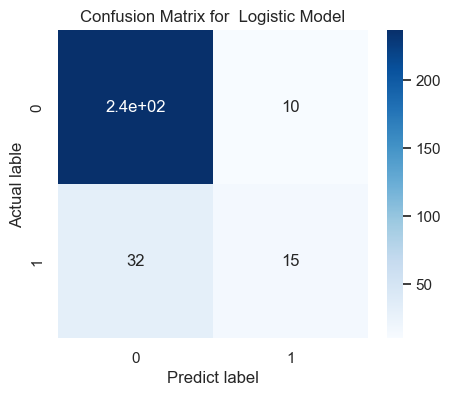

In [43]:
plt.figure(figsize=(5,4))
sns.heatmap(confu_matrix , annot=True,cmap="Blues")

plt.title("Confusion Matrix for  Logistic Model")
plt.xlabel("Predict label")
plt.ylabel("Actual lable")
plt.savefig("confusion_matrix_Logistic_R.png", dpi=300,bbox_inches="tight")
plt.show()

 Accuracy : 85.7%
 Confusion Matrix:
 True Nagetive of : 237
 True Positive of : 15
 False Nagetive of : 32
 Flase Positive : 10
 Roc Auc : 0.639

The model correctly clasified who stayed but missed several attrition cases

In [44]:
y_prob = log_model.predict(x_test)
roc_auc = roc_auc_score(y_test,y_prob)
print("Roc_Auc Score \n:", roc_auc)

Roc_Auc Score 
: 0.6393315531053492


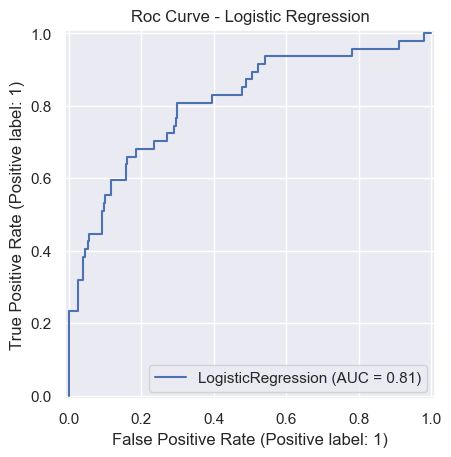

In [45]:
fpr, tpr, threshold = roc_curve(y_test,y_prob)
roc_auc = roc_auc_score(y_test,y_prob)
RocCurveDisplay.from_estimator(log_model,x_test,y_test)
plt.title("Roc Curve - Logistic Regression")
plt.savefig("roc_logistic.png", dpi=300,bbox_inches="tight")
plt.show()

In [46]:
log_bal = LogisticRegression(class_weight='balanced')
log_bal.fit(x_train,y_train)

LogisticRegression(class_weight='balanced')

In [47]:
log_pred_bal = log_bal.predict(x_test)

In [48]:
accu_scores= accuracy_score(y_test, log_pred_bal)
clasi_report = classification_report(y_test, log_pred_bal)
conf_bal_matrix = confusion_matrix(y_test, log_pred_bal)

print("Accuracy Score \n :", accu_scores)
print("------------------------------------")
print("Classification Report \n:", clasi_report)
print("------------------------------------")
print("Confusion Matrix \n:", conf_bal_matrix)

Accuracy Score 
 : 0.7448979591836735
------------------------------------
Classification Report 
:               precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.74       294
   macro avg       0.63      0.69      0.64       294
weighted avg       0.82      0.74      0.77       294

------------------------------------
Confusion Matrix 
: [[190  57]
 [ 18  29]]


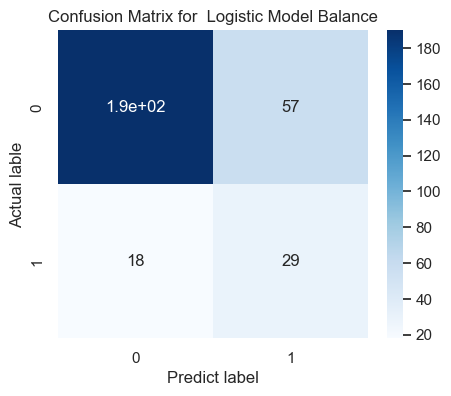

In [49]:
plt.figure(figsize=(5,4))
sns.heatmap(conf_bal_matrix , annot=True,cmap="Blues")

plt.title("Confusion Matrix for  Logistic Model Balance")
plt.xlabel("Predict label")
plt.ylabel("Actual lable")
plt.savefig("confusion_matrix_Logistic_balance.png", dpi=300,bbox_inches="tight")
plt.show()

 Accuracy : 74.4%
 Confusion Matrix:
 True Nagetive of : 190
 True Positive of : 29
 False Nagetive of : 18
 Flase Positive : 57
 Roc Auc : 0.693

 Class wieght slightlt improved the detection of employee who likely to leave, althought it increase false positve.
 This achieved the meet overall Propability among al models


In [50]:
y_prob = log_bal.predict(x_test)
roc_auc = roc_auc_score(y_test,y_prob)
print("Roc_Auc Score \n:", roc_auc)

Roc_Auc Score 
: 0.693126022913257


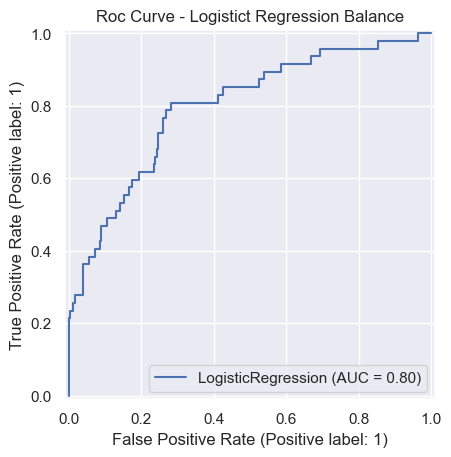

In [51]:
fpr, tpr, threshold = roc_curve(y_test,y_prob)
roc_auc = roc_auc_score(y_test,y_prob)
RocCurveDisplay.from_estimator(log_bal,x_test,y_test)
plt.title("Roc Curve - Logistict Regression Balance")
plt.savefig("roc_logistic_Balance.png", dpi=300,bbox_inches="tight")
plt.show()

Hyperparameter for Logistic Regression class wieght

In [52]:
param_grid = {
    "C":[0.01,0.1,1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "max_iter":[100,500,1000],
}
# C : Strong Regularaization
# Solve : Best Coefficient (wieght)

In [53]:
# model the GridsearchCV 

grid_param_best = GridSearchCV(
    estimator=log_bal,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [54]:
grid_param_best.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(class_weight='balanced'),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'max_iter': [100, 500, 1000],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [55]:
log_balan_pred = grid_param_best.predict(x_test)

In [56]:
ac_score =accuracy_score(y_test,log_balan_pred)
clas_repor = classification_report(y_test,log_balan_pred)
con_matrix = confusion_matrix(y_test,log_balan_pred)

print("Accuracy Score \n :", ac_score)
print("------------------------------------")
print("Classification Report \n:", clas_repor)
print("------------------------------------")
print("Confusion Matrix \n:", con_matrix)

Accuracy Score 
 : 0.7448979591836735
------------------------------------
Classification Report 
:               precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.74       294
   macro avg       0.63      0.69      0.64       294
weighted avg       0.82      0.74      0.77       294

------------------------------------
Confusion Matrix 
: [[190  57]
 [ 18  29]]


In [57]:
best_param = grid_param_best.best_params_
best_estimator = grid_param_best.best_estimator_
best_score = grid_param_best.best_score_


print("Best Paramter \n:",best_param)
print("------------------------------")
print("------------------------------")
print("Best Score \n:",best_score)

Best Paramter 
: {'C': 1, 'max_iter': 100, 'solver': 'lbfgs'}
------------------------------
------------------------------
Best Score 
: 0.5099780559823314


GridSearchCV was used to identify the optimum hyperparameter for logistic Regression Class wieght,
because is the one that outperformed the attrition well, so GridsearchCV turn to improved the 
logistic balance over all the performance.
GridSearchCV select the best paramter of (C = 1, solve = IBbfgs, max_iteration = 100).
The turn model to achieved 74.49% accuracy.
Recall improved to 62%, enabling better identication of employees at rist of atty=ition.
Hyperparameter turnig improved the model ability to detect the attrition , makr it more relaible for attrition prediction.

    

# Decision Model

In [58]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [59]:
y_pred_dt= dt_model.predict(x_test)

In [60]:
accu_scores_dt= accuracy_score(y_test, y_pred_dt)
clasi_report_dt = classification_report(y_test,y_pred_dt)
confu_matrix_dt = confusion_matrix(y_test,y_pred_dt)

print("Accuracy Score \n :", accu_scores_dt)
print("------------------------------------")
print("Classification Report \n:", clasi_report_dt)
print("------------------------------------")
print("Confusion Matrix \n:", confu_matrix_dt)

Accuracy Score 
 : 0.7959183673469388
------------------------------------
Classification Report 
:               precision    recall  f1-score   support

           0       0.88      0.87      0.88       247
           1       0.37      0.38      0.38        47

    accuracy                           0.80       294
   macro avg       0.62      0.63      0.63       294
weighted avg       0.80      0.80      0.80       294

------------------------------------
Confusion Matrix 
: [[216  31]
 [ 29  18]]


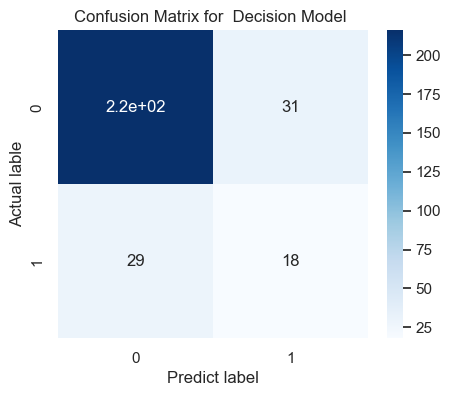

In [61]:
plt.figure(figsize=(5,4))
sns.heatmap(confu_matrix_dt , annot=True,cmap="Blues")

plt.title("Confusion Matrix for  Decision Model ")
plt.xlabel("Predict label")
plt.ylabel("Actual lable")
plt.savefig("confusion_decision_tree.png", dpi=300,bbox_inches="tight")
plt.show()

 Accuracy : 80.0%
 Confusion Matrix:
 True Nagetive of : 219
 True Positive of : 18
 False Nagetive of :29 
 Flase Positive : 31
 Roc Auc : 0.628

 The decision model identified attrition than Logistic model over confusion matrix,
 but decision model outperformed on recall and f1 result, also base on probability has lower value.


In [62]:
y_prob = dt_model.predict(x_test)
roc_auc = roc_auc_score(y_test,y_prob)
print("Roc_Auc Score \n:", roc_auc)

Roc_Auc Score 
: 0.6287363252648808


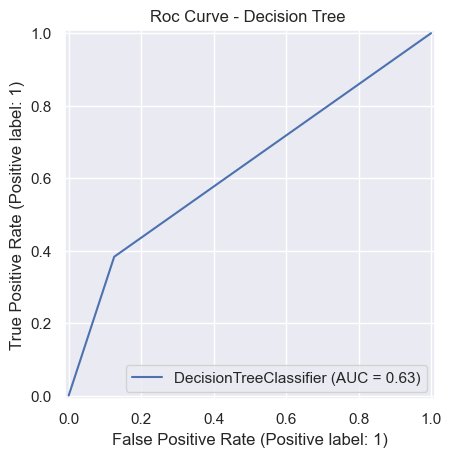

In [63]:
fpr, tpr, threshold = roc_curve(y_test,y_prob)
roc_auc = roc_auc_score(y_test,y_prob)
RocCurveDisplay.from_estimator(dt_model,x_test,y_test)
plt.title("Roc Curve - Decision Tree ")
plt.savefig("roc_decision_tree.png", dpi=300,bbox_inches="tight")
plt.show()

In [64]:
dt_balance = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_balance.fit(x_train,y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [65]:
dt_pred_balan = dt_balance.predict(x_test)

In [66]:
ccu_scores_dt= accuracy_score(y_test, dt_pred_balan)
clasi_report_dt = classification_report(y_test, dt_pred_balan)
confu_m_dt_bala = confusion_matrix(y_test, dt_pred_balan)

print("Accuracy Score \n :", accu_scores_dt)
print("------------------------------------")
print("Classification Report \n:", clasi_report_dt)
print("------------------------------------")
print("Confusion Matrix \n:", confu_m_dt_bala)

Accuracy Score 
 : 0.7959183673469388
------------------------------------
Classification Report 
:               precision    recall  f1-score   support

           0       0.89      0.87      0.88       247
           1       0.39      0.45      0.42        47

    accuracy                           0.80       294
   macro avg       0.64      0.66      0.65       294
weighted avg       0.81      0.80      0.80       294

------------------------------------
Confusion Matrix 
: [[214  33]
 [ 26  21]]


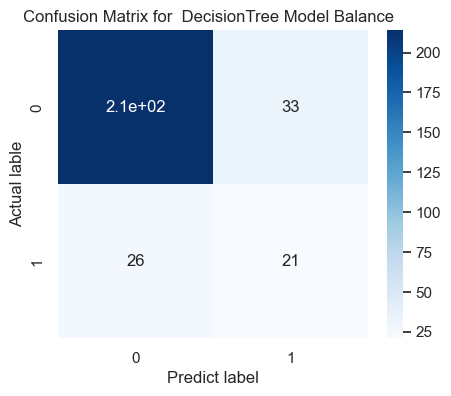

In [67]:
plt.figure(figsize=(5,4))
sns.heatmap(confu_m_dt_bala , annot=True,cmap="Blues")

plt.title("Confusion Matrix for  DecisionTree Model Balance  ")
plt.xlabel("Predict label")
plt.ylabel("Actual lable")
plt.savefig("confusion_matrix_decision_balance.png", dpi=300,bbox_inches="tight")
plt.show()

 Accuracy : 78.5%
 Confusion Matrix:
 True Nagetive of : 214
 True Positive of : 21
 False Nagetive of : 26
 Flase Positive : 33
 Roc Auc : 0.66

 Insite: Balance improved the recall abd detected more employees at risk of leaving.
 performance improved overthe original Decision Tree, also the probability performed well then logistic regression.


In [68]:
y_prob = dt_balance.predict(x_test)
roc_auc = roc_auc_score(y_test,y_prob)

print("Roc_Auc Score \n:", roc_auc)

Roc_Auc Score 
: 0.6566026358859505


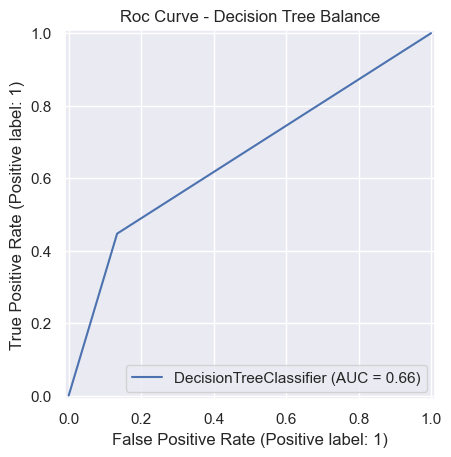

In [69]:
fpr, tpr, threshold = roc_curve(y_test,y_prob)
roc_auc = roc_auc_score(y_test,y_prob)
RocCurveDisplay.from_estimator(dt_balance,x_test,y_test)
plt.title("Roc Curve - Decision Tree Balance")
plt.savefig("roc_decision_tree_balanca.png", dpi=300,bbox_inches="tight")
plt.show()

# Random Forest Model

In [70]:
rf_model = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [71]:
y_pred_rf = rf_model.predict(x_test)

In [72]:
accu_scores_rf= accuracy_score(y_test, y_pred_rf)
clasi_report_rf = classification_report(y_test,y_pred_rf)
confu_matrix_rf = confusion_matrix(y_test,y_pred_rf)

print("Accuracy Score \n :", accu_scores_rf)
print("------------------------------------")
print("Classification Report \n:", clasi_report_rf)
print("------------------------------------")
print("Confusion Matrix \n:", confu_matrix_rf)

Accuracy Score 
 : 0.8333333333333334
------------------------------------
Classification Report 
:               precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294

------------------------------------
Confusion Matrix 
: [[241   6]
 [ 43   4]]


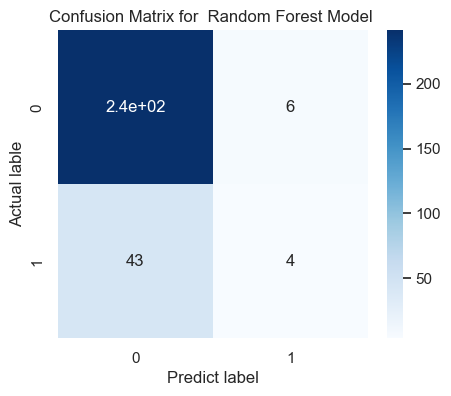

In [73]:
plt.figure(figsize=(5,4))
sns.heatmap(confu_matrix_rf , annot=True,cmap="Blues")

plt.title("Confusion Matrix for  Random Forest Model ")
plt.xlabel("Predict label")
plt.ylabel("Actual lable")
plt.savefig("confusion_matrix_random_forest.png", dpi=300,bbox_inches="tight")
plt.show()

 Accuracy : 83.3%
 Confusion Matrix:
 True Nagetive of : 241
 True Positive of : 4
 False Nagetive of : 43
 Flase Positive : 6
 Roc Auc : 0.53

Iniste: The model predict employees who stayed very well but failed to identify most attrition cases.
it showed the weakest discrimination among all models.


In [74]:
y_prob = rf_model.predict(x_test)
roc_auc = roc_auc_score(y_test,y_prob)

print("Roc_Auc Score \n:", roc_auc)

Roc_Auc Score 
: 0.5304074425015074


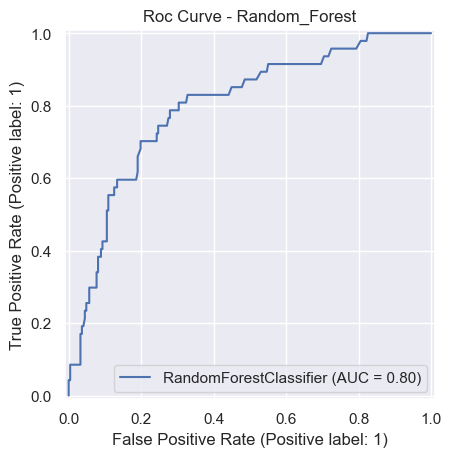

In [75]:
fpr, tpr, threshold = roc_curve(y_test,y_prob)
roc_auc = roc_auc_score(y_test,y_prob)
RocCurveDisplay.from_estimator(rf_model,x_test,y_test)
plt.title("Roc Curve - Random_Forest")
plt.savefig("roc_random_forest.png", dpi=300,bbox_inches="tight")
plt.show()

In [76]:
rf_balance = RandomForestClassifier(n_estimators=1000, class_weight='balanced', random_state=42)
rf_balance.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=1000,
                       random_state=42)

In [77]:
rf_pred_bala = rf_balance.predict(x_test)

In [78]:
accu_scores_rf= accuracy_score(y_test,rf_pred_bala)
clasi_report_rf = classification_report(y_test,rf_pred_bala)
confu_matrix_rf = confusion_matrix(y_test,rf_pred_bala)

print("Accuracy Score \n :", accu_scores_rf)
print("------------------------------------")
print("Classification Report \n:", clasi_report_rf)
print("------------------------------------")
print("Confusion Matrix \n:", confu_matrix_rf)

Accuracy Score 
 : 0.8435374149659864
------------------------------------
Classification Report 
:               precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

------------------------------------
Confusion Matrix 
: [[244   3]
 [ 43   4]]


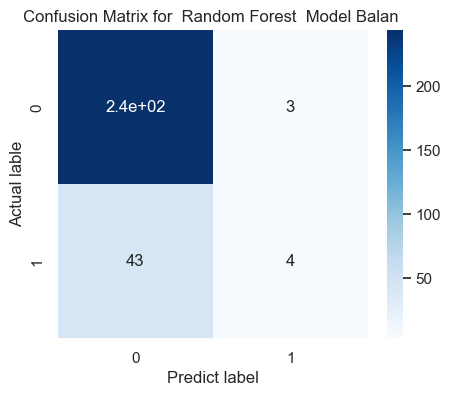

In [79]:
plt.figure(figsize=(5,4))
sns.heatmap(confu_matrix_rf , annot=True,cmap="Blues")

plt.title("Confusion Matrix for  Random Forest  Model Balan ")
plt.xlabel("Predict label")
plt.ylabel("Actual lable")
plt.savefig("confusion_matrix_random_forest_balance.png", dpi=300,bbox_inches="tight")
plt.show()

Accuracy : 84.3%
 Confusion Matrix:
 True Nagetive of : 244
 True Positive of : 4
 False Nagetive of : 43
 Flase Positive : 3
 Roc Auc : 0.54


In [86]:
y_prob = rf_balance.predict(x_test)
roc_auc = roc_auc_score(y_test,y_prob)
print("Roc_Auc Score \n:", roc_auc)

Roc_Auc Score 
: 0.5364803169954345


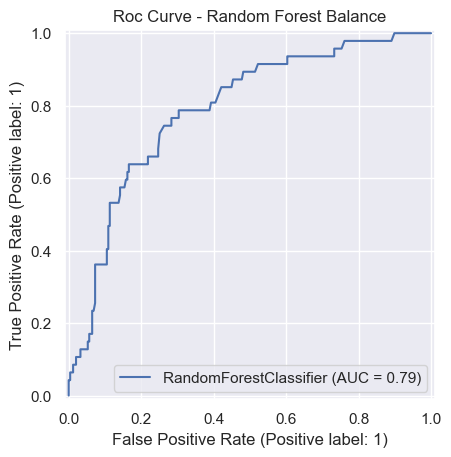

In [81]:
fpr, tpr, threshold = roc_curve(y_test,y_prob)
roc_auc = roc_auc_score(y_test,y_prob)
RocCurveDisplay.from_estimator(rf_balance,x_test,y_test)
plt.title("Roc Curve - Random Forest Balance")
plt.savefig("roc_random_forest_balance.png", dpi=300,bbox_inches="tight")
plt.show()

In [82]:
# Hyperparameters Tuning

param_grid = {
    "max_depth": [3,5,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "criterion": ["gini","entropy"]
}
    

In [83]:
grid_param = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [84]:
grid_param.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [85]:
print(grid_param.best_params_)
print(grid_param.best_score_)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
0.34595935940198236
